In [1]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt

### Plot True colors

C:\Users\sebas\AppData\Local\Temp\ipykernel_9300\2027275635.py:4: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  band = src.read(1)


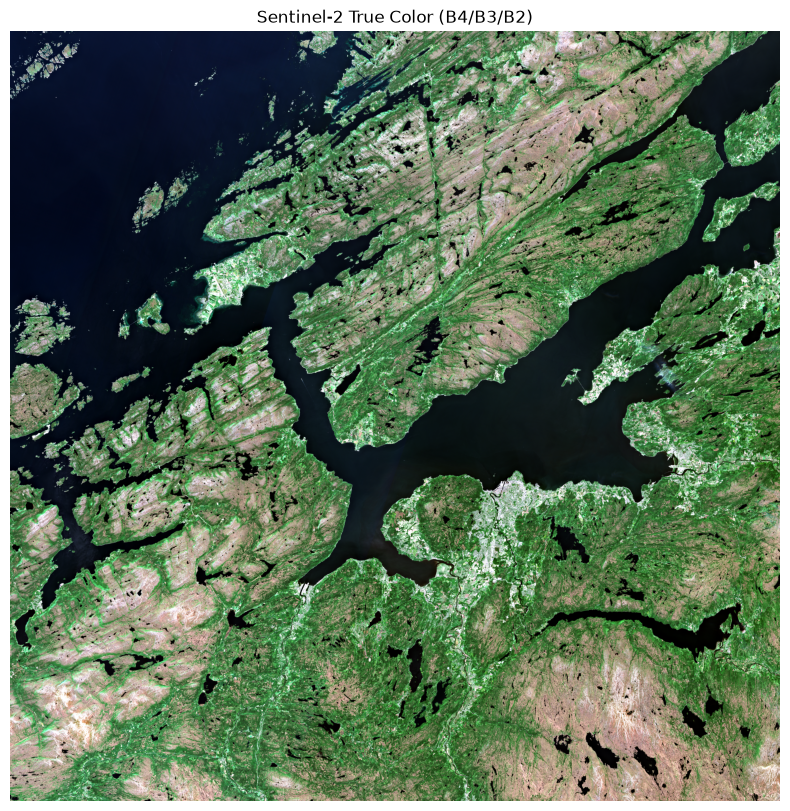

In [3]:
def read_band(band_path):
    """Read a Sentinel-2 JP2 band."""
    with rasterio.open(band_path) as src:
        band = src.read(1)
        profile = src.profile
    return band, profile


def stretch(image, lower=2, upper=98):
    """
    Contrast stretch for better visualization.
    """
    p_low, p_high = np.percentile(image, (lower, upper))
    image = np.clip((image - p_low) / (p_high - p_low), 0, 1)
    return image


# ---------------------------------------------------------------------
# Change this path to your Sentinel-2 SAFE directory
# ---------------------------------------------------------------------
SAFE_FOLDER = r"../Sentinel/S2C_MSIL2A_20250613T104641_N0511_R051_T32VNR_20250613T134507.SAFE"

IMG_DATA = os.path.join(
    SAFE_FOLDER,
    "GRANULE"
)

# Find the GRANULE directory automatically
granule = os.listdir(IMG_DATA)[0]
IMG_DATA = os.path.join(
    IMG_DATA,
    granule,
    "IMG_DATA",
    "R10m"
)

# Band paths (10 m resolution)
red_path   = os.path.join(IMG_DATA, [f for f in os.listdir(IMG_DATA) if "_B04_" in f][0])
green_path = os.path.join(IMG_DATA, [f for f in os.listdir(IMG_DATA) if "_B03_" in f][0])
blue_path  = os.path.join(IMG_DATA, [f for f in os.listdir(IMG_DATA) if "_B02_" in f][0])

# Read bands
red, profile = read_band(red_path)
green, _ = read_band(green_path)
blue, _ = read_band(blue_path)

# Convert to float
red = red.astype(np.float32)
green = green.astype(np.float32)
blue = blue.astype(np.float32)

# Stack RGB
rgb = np.dstack([
    stretch(red),
    stretch(green),
    stretch(blue)
])

# Plot
plt.figure(figsize=(10, 10))
plt.imshow(rgb)
plt.title("Sentinel-2 True Color (B4/B3/B2)")
plt.axis("off")
plt.show()

### Plot NDVI (vegetation)

C:\Users\sebas\AppData\Local\Temp\ipykernel_9300\2027275635.py:4: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  band = src.read(1)


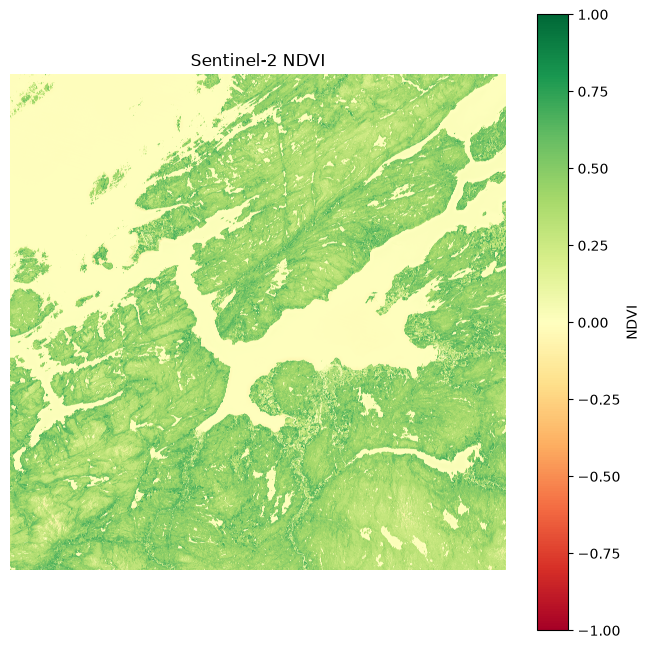

In [4]:
# Paths to Red (B04) and NIR (B08)
nir_path = os.path.join(IMG_DATA, [f for f in os.listdir(IMG_DATA) if "_B08_" in f][0])

nir, _ = read_band(nir_path)

red = red.astype(float)
nir = nir.astype(float)

ndvi = (nir - red) / (nir + red + 1e-10)

plt.figure(figsize=(8,8))
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI")
plt.title("Sentinel-2 NDVI")
plt.axis("off")
plt.show()